In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import math
import torch
import pickle
from collections import Counter
import sys
import os

In [9]:
sys.path.append(os.path.abspath(".."))

from lago_data_model.model_utils import eval_predictions, compare_models, save_model

In [10]:
RANDOM_STATE = 42
TEST_SIZE = 0.3

## Load Data

In [11]:
with open("all_segments.pkl", "rb") as f:
    segments = pickle.load(f)

In [12]:
pulses_df = pd.read_csv("pulses.csv")

In [13]:
drop_cols = ["row_id", "start_idx",	"min_idx",	"end_idx"]

In [14]:
X = pulses_df.drop(columns=drop_cols, errors="ignore")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Load k-means Labels

In [15]:
with open('kmeans_labels.pkl', 'rb') as handle:
    labels = pickle.load(handle)

# Modelo MLP

#### Dividir dataset

In [16]:
#Xtr, Xte, ytr, yte = train_test_split(X_scaled, labels, test_size=0.2, random_state=42, stratify=labels)

In [17]:
X.head()

,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,113.0,195.0,82.0,12,528.0,6,3,8,13.666667
1,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
2,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
3,157.0,195.0,38.0,153,396.0,5,76,76,38.000000
4,157.0,195.0,38.0,153,396.0,5,76,76,38.000000


In [18]:
feature_cols = list(X.columns)

In [19]:
X_trval, X_te, y_trval, y_te = train_test_split(
    X, labels, test_size=TEST_SIZE, random_state=42, stratify=labels
)
# luego separamos val del resto
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trval, y_trval, test_size=0.25, random_state=42, stratify=y_trval
)

In [20]:
# --- scaler (ajustar SOLO con train) ---
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_te_s  = scaler.transform(X_te)

num_classes = len(np.unique(labels))

## MLP 

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses
import matplotlib.pyplot as plt

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs visibles: {len(gpus)} → usando TensorFlow con GPU")
    except Exception as e:
        print("No se pudo configurar memory growth:", e)
else:
    print("No se detectó GPU: se entrenará en CPU")

GPUs visibles: 1 → usando TensorFlow con GPU


In [4]:
def build_mlp(in_dim: int, hidden_size1: int, hidden_size2: int, out_dim: int) -> keras.Model:
    return keras.Sequential([
        layers.Input(shape=(in_dim,)),
        layers.Dense(hidden_size1, activation='relu'),
        layers.Dense(hidden_size2, activation='relu'),
        layers.Dense(out_dim)  # sin activación: logits
    ], name="MLP")

In [5]:
class PrintLRChange(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        opt = self.model.optimizer
        lr = float(tf.keras.backend.get_value(opt.learning_rate))
        # Cuando ReduceLROnPlateau ajusta el LR, Keras ya imprime (verbose=1). Este callback asegura el log cada época.
        print(f"[Epoch {epoch+1:03d}] current_lr = {lr:.6f}")

In [24]:
def train_model_tf(model: keras.Model,
                   Xtr, ytr, Xte, yte,
                   epochs: int = 20,
                   bs: int = 64,
                   lr: float = 1e-3,
                   patience: int = 5,
                   lr_patience: int = 5):

    # Datasets (equivalente a DataLoader)
    train_ds = tf.data.Dataset.from_tensor_slices((Xtr, ytr)).shuffle(len(Xtr)).batch(bs).prefetch(tf.data.AUTOTUNE)
    val_ds   = tf.data.Dataset.from_tensor_slices((Xte, yte)).batch(bs).prefetch(tf.data.AUTOTUNE)

    # Optimizador y pérdida (y* deben ser enteros de clase; si tienes one-hot, usa CategoricalCrossentropy)
    opt = optimizers.Adam(learning_rate=lr)
    loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

    # Callbacks: Reduce LR on Plateau + EarlyStopping (igual lógica que en PyTorch)
    cb = [
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=lr_patience, verbose=1, min_delta=0.0),
        callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1),
        PrintLRChange(),
    ]

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1,
        callbacks=cb
    )

    # Gráfico de pérdidas
    plt.figure(figsize=(6,4))
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Curva de aprendizaje')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, hist

In [21]:
model_params = {
    "input_size":  X_tr_s.shape[1],
    "hidden_size1": 128,
   "hidden_size2": 32,
    "output_size": len(np.unique(labels)),
    "epochs": 300,
    "lr": 0.0005,
    "batch_size": 1500
}

In [22]:
mlp_tf = build_mlp(
    in_dim=model_params["input_size"],
    hidden_size1=model_params["hidden_size1"],
    hidden_size2=model_params["hidden_size2"],
    out_dim=model_params["output_size"]
)

I0000 00:00:1760846124.092629     256 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13294 MB memory:  -> device: 0, name: NVIDIA A2, pci bus id: 0000:44:00.0, compute capability: 8.6
2025-10-19 03:55:24.906747: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykern/cuda_nvcc
  ipykern/cuda_nvdisasm
  ipykern/nvidia_nvshmem
  
  /usr/local/cuda
  /opt/cuda
  /opt/conda/lib/python3.11/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /opt/conda/lib/python3.11/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
 

InternalError: {{function_node __wrapped__FloorMod_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:FloorMod] name: 

=== Métricas agregadas ===
Macro     -> P: 0.9983 | R: 0.9979 | F1: 0.9981
Weighted  -> P: 0.9994 | R: 0.9994 | F1: 0.9994

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    155333
           1       1.00      1.00      1.00     60352
           2       1.00      1.00      1.00    375765
           3       1.00      1.00      1.00     68033
           4       1.00      1.00      1.00     30976
           5       1.00      1.00      1.00       812
           6       1.00      0.99      0.99       310
           7       1.00      1.00      1.00     18355

    accuracy                           1.00    709936
   macro avg       1.00      1.00      1.00    709936
weighted avg       1.00      1.00      1.00    709936



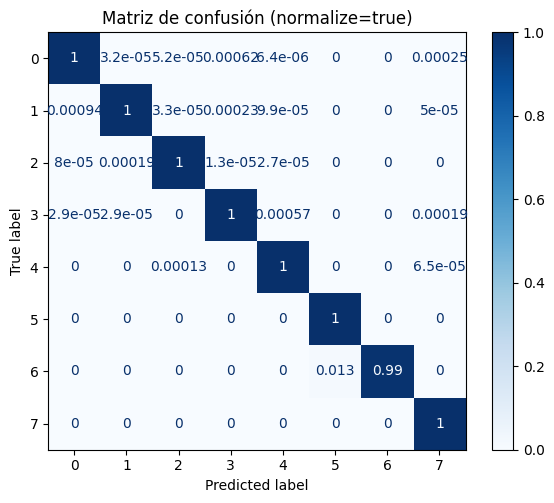


ROC-AUC multiclase:
  micro-average: 1.0000
  macro-average (ovr): 1.0000


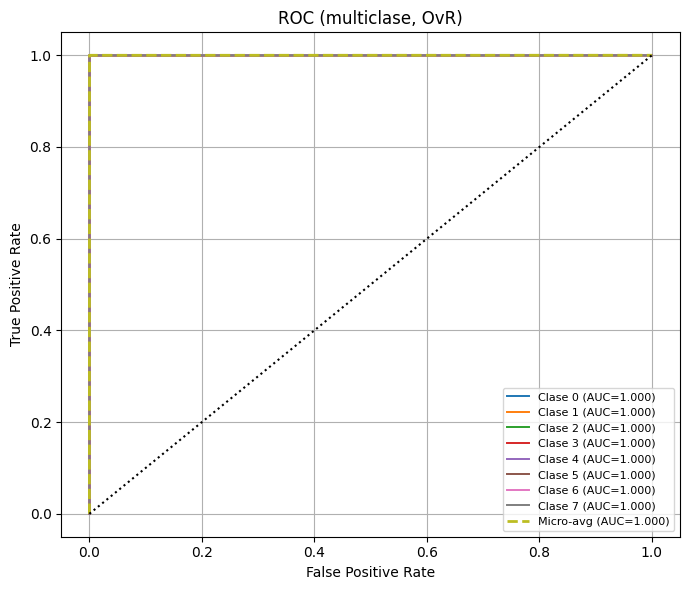


Average Precision multiclase:
  micro-average AP: 1.0000
  clase 0 AP: 1.0000
  clase 1 AP: 1.0000
  clase 2 AP: 1.0000
  clase 3 AP: 1.0000
  clase 4 AP: 1.0000
  clase 5 AP: 1.0000
  clase 6 AP: 1.0000
  clase 7 AP: 1.0000


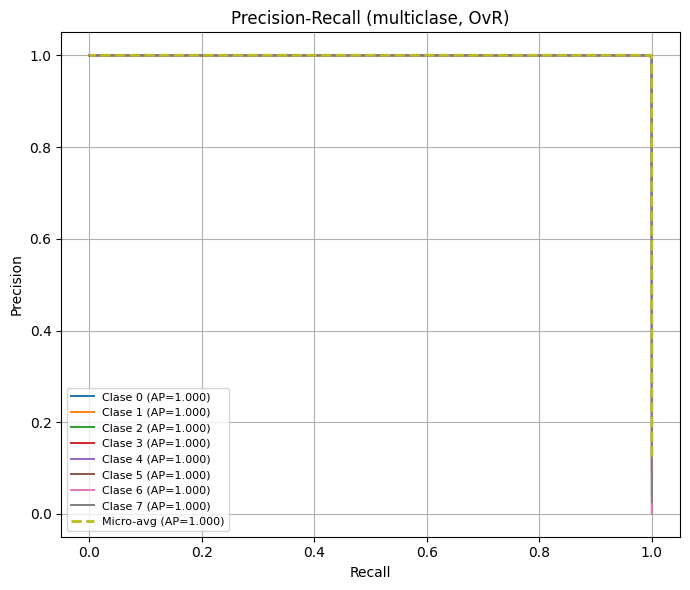

In [39]:
_ = eval_predictions(y_true=y_te, y_pred=proba_mlp, plot_cm=True, plot_roc=True, plot_pr=True)